In [24]:
import os
import glob
import numpy as np
from scipy import io
from tqdm import tqdm


from utils.plots import *
from utils.data import *
from utils.stats_perform import *
import utils.drl as utils

np.random.seed(0)


In [21]:
g_dir= '/Users/sromeropinto/Library/CloudStorage/GoogleDrive-sromeropinto@g.harvard.edu/My Drive/Data/LHb/Ju_LHb_Lesions/'
data_dir = os.path.join(g_dir,  'lightidunits')
save_dir = os.path.join('analysis')
groups = ['control','lesion']
var_names = ['input_fr','da_conc','d1_occ','d2_occ']
colors_g = ['black','red','purple']
tr_rew = ['reward','omission']
tr_cs = ['90%','50%','10%']
f_size = 12
alpha_p = .05
max_trials = 200
n_samp = 3900
nf = [45,44]

Load results from simulations: saved in a single-neuron matrix


**Trial types**

- `1`:  90% rewarded
- `2`:  90% omission
- `3`:  50% rewarded
- `4`:  50% omission
- `5`:  10% rewarded
- `6`:  10% omission

Output variables from loading: 
- `mu_var_cells`: (N groups) x(N variables) x (N trialtypes) x (N reward types) x (N cells) x (N samples per trial) 
- `single_trial_var_cells`: (N groups) x(N variables) x (N trialtypes) x (N reward types) x (N cells) x (N samples per trial) x (N trials)

Where: 
- N groups = 2  (control, lesion)
- N variables = 4 (input firing rate, DA concentration, D1 occupancy, D2 occupancy)
- N trialtypes = 6 (90% reward, 50% reward, 10% reward)
- N reward types = 2 (rewarded, omission)
- N cells = 45, 44 for each group
- N samples per trial = 3900 (`n_samp`)

In [33]:

id_trial_plot = [[1,3,5],[2,4,6]] 
mu_var_cells = np.empty((len(groups),len (var_names),len(id_trial_plot),len(id_trial_plot[0]),45,n_samp))
single_trial_var_cells =  np.empty((len(groups),len(var_names),len(id_trial_plot),len(id_trial_plot[0]),45,n_samp,max_trials))
for ig in np.arange(len(groups)):
    data_path = os.path.join(data_dir ,groups[ig])
    file_list = glob.glob(data_path + "/*formatteda.mat")
    print('loading ' + groups[ig])
    file_list =file_list[:nf[ig]]
    for (id_unit) in  tqdm(range(len(file_list))):
        unit = io.loadmat(file_list[id_unit],squeeze_me=True,struct_as_record=False)
        trial_types, trial_names = unit['S'].TrialTypes, unit['S'].TrialNames
        temp = np.asarray(unit['simulation_results'].time_ax)
        ind = np.unravel_index(np.argmax(temp, axis=None), temp.shape)
        for iv in np.arange(len(var_names)):
            var_name = var_names[iv]
            exec('var = np.asarray(unit["simulation_results"].' + var_name + ')')
            time_ax = np.asarray(unit['simulation_results'].time_ax)[:,ind[1]]
            for ir in np.arange(len(id_trial_plot)):
                for i in np.arange(len(id_trial_plot[ir])):
                    id_trials = np.argwhere(np.isin(trial_types, id_trial_plot[ir][i])==1)[:,0]
                    id_trials = id_trials[id_trials<max_trials]
                    var_trials = var[:,id_trials]
                    var_trials[var_trials<=0] = np.nan
                    if iv==1:
                        var_trials[var_trials>3000]=np.nan # TODO
                    elif iv>=2:
                        var_trials[var_trials>1]=np.nan
                    mu_var = np.nanmean(var_trials,axis=1)
                    mu_var_cells[ig,iv,ir,i,id_unit,:]=mu_var
                    single_trial_var_cells[ig,iv,ir,i,id_unit,:,0:var_trials.shape[1]]= var_trials
                    ids_ = [np.argwhere(ii==0).flatten() for ii in single_trial_var_cells[ig,iv,ir,i,id_unit,:,:].T]
                    for (ii,ids) in enumerate(ids_):
                        single_trial_var_cells[ig,iv,ir,i,id_unit,ids,ii] = np.nan

loading control


  0%|          | 0/45 [00:00<?, ?it/s]/var/folders/7s/h7n9pv413rl46rgzy1w1w54w0000gn/T/ipykernel_60462/3647226443.py:29: RuntimeWarning: Mean of empty slice
  mu_var = np.nanmean(var_trials,axis=1)
100%|██████████| 45/45 [00:09<00:00,  4.79it/s]


loading lesion


100%|██████████| 44/44 [01:30<00:00,  2.06s/it]


## Figure 6c
Plot mean responses from dopamine biophysical simulations across neurons for each group (*Lesion* : red , *Control* : black)

**Variables plotted:**

*Input to model:*
- `input_fr` : input firing rates from the LHb lesion dataset
  
*Outputs from model:*
- `da_conc`: Dopamine concentration 
- `d1_occ` : D1 receptor occupancy
- `d2_occ`: D2 receptor occupancy

*Note*: The windows of responses differs between the input firing rates (faster timescale) and the rest of variables (slower timescales)

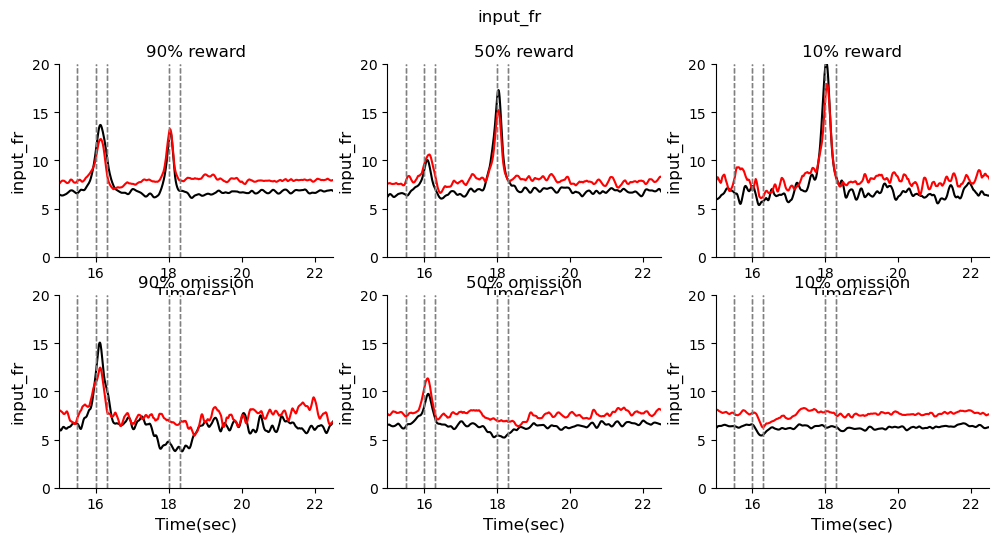

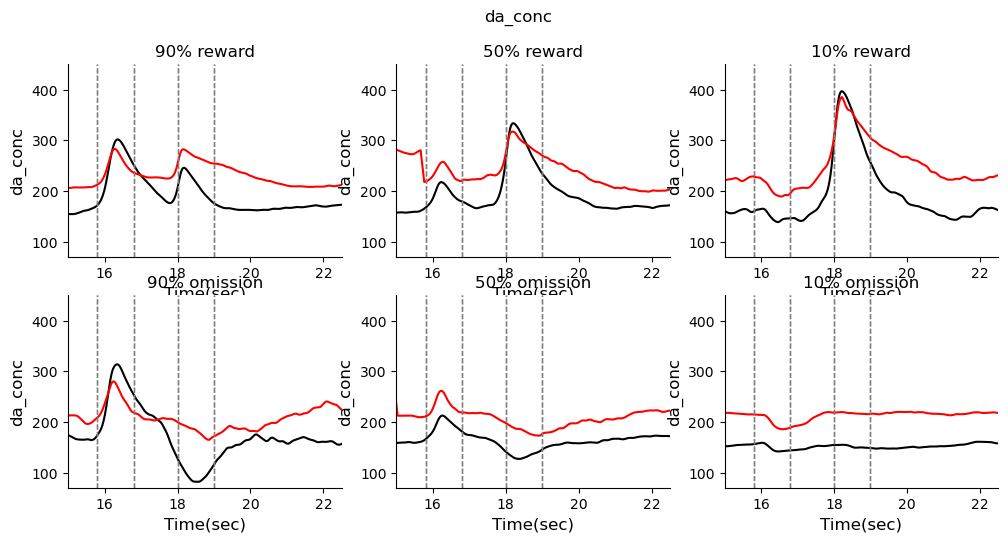

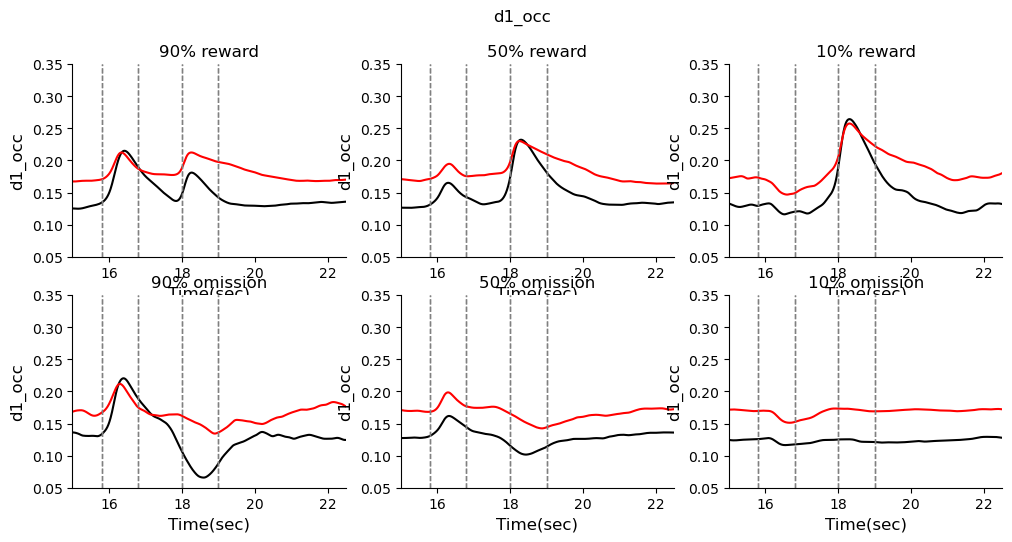

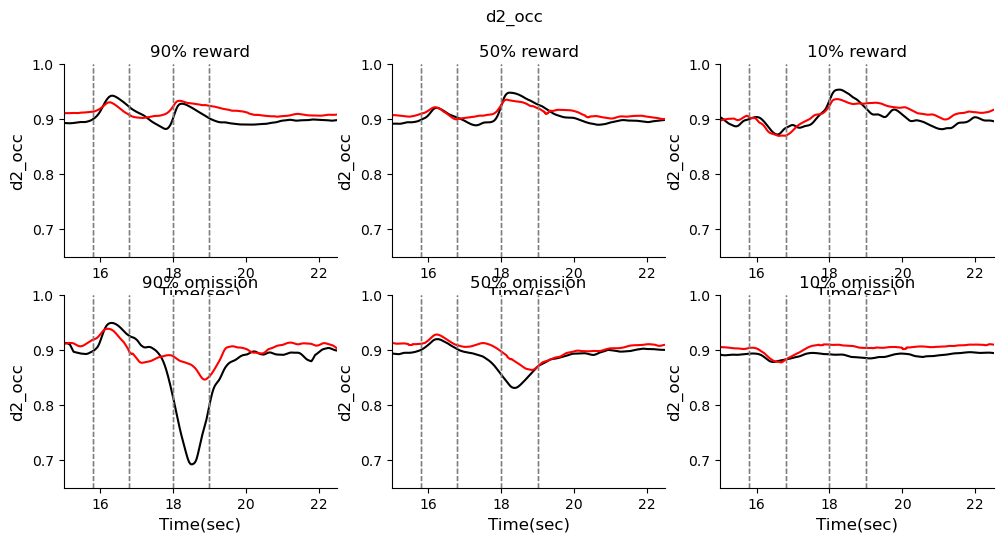

In [98]:
mu_var_cells[mu_var_cells<=0]=np.nan
mu_var_cells[1,:,:,:,4,:]=np.nan # TODO
window_lists = [[ [16,16.3],[18,18.3],[14.5,15.5]], [[15.8,16.8],[18,19],[5.,10.]]]  # Windows of responses 
yl = [[0 , 20],[70 ,450],[.05, .35],[.65,1]] 
xl = [[5.,30],[5,30],[5,30],[5,30]]
idwindow = [0,1,1,1]
for iv in  np.arange(4):
    window_list = window_lists[idwindow[iv]]
    fig, ax= plt.subplots(2,3,figsize=(12, 5.5))    
    for ig in np.arange(len(groups)):
        for ir in np.arange(len(id_trial_plot)):
            for i in np.arange(len(id_trial_plot[ir])):
                tt = mu_var_cells[ig,iv,ir,i,:,:]
                temp = smooth(np.nanmean(tt,axis=0),10)
                ax[ir,i].plot(time_ax,temp,color = colors_g[ig])
                [[ax[ir,i].plot([iw[ii],iw[ii]],[yl[iv][0],yl[iv][1]],'--',color='grey',linewidth=1) for ii in range(len(iw))] for iw in window_list]
                ax[ir,i].set_xlim(xl[iv][0],xl[iv][1])
                ax[ir,i].set_ylim(yl[iv][0],yl[iv][1])
                plot_config(ax[ir,i],'Time(sec)',var_names[iv],f_size,False)
                title_(ax[ir,i],tr_cs[i]+ ' '+ tr_rew[ir])
                ax[ir,i].set_xlim([15,22.5])
    plt.suptitle(var_names[iv])

## Figure 6 e,f
Compute baselines of the same simulation variables  as above

Code flow:
1. Compute baseline activity on the window of interest `window_base` for each group
2. Plot boxplots of baseline distributions for each group
3. Perform test for: 
    a. normality of distribution 
    b. difference of distributions between control and lesion groups

Output varaible:
- `base_cells`: (N groups) x (N variables) x (N cells)

/var/folders/7s/h7n9pv413rl46rgzy1w1w54w0000gn/T/ipykernel_60462/2513906344.py:11: RuntimeWarning: Mean of empty slice
  mu_base = np.nanmean(var_trials,axis=1)


The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution


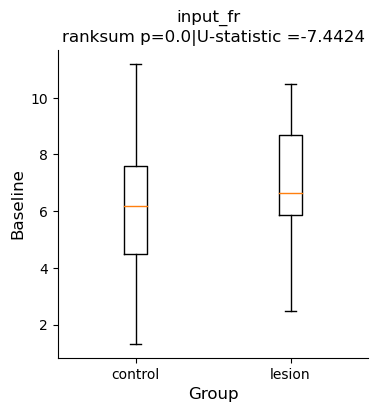

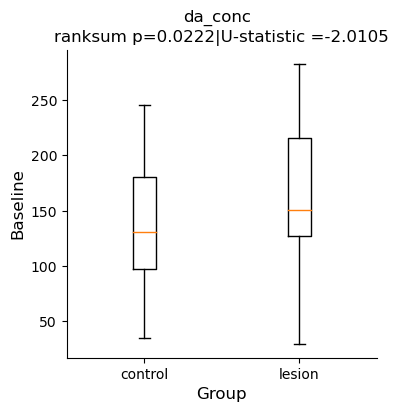

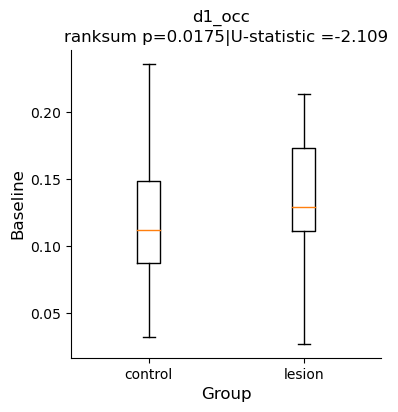

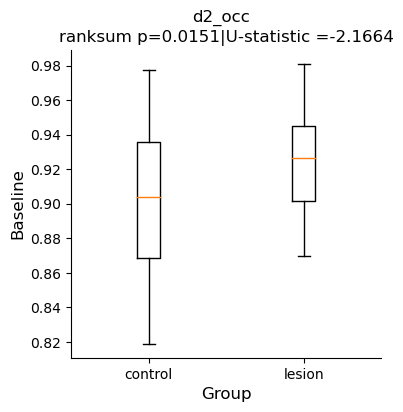

In [99]:
# Compute baselines:
window_base = [14.5,15.5]
base_cells  = np.empty((len(groups),len(var_names),45))
for ig in np.arange(len(groups)):
    for iv in  np.arange(4):
        id_s = np.argwhere(time_ax>window_base[0]).flatten()[0]
        id_e = np.argwhere(time_ax>window_base[1]).flatten()[0]
        var_trials = single_trial_var_cells[ig,iv,:,:,:,id_s:id_e,:].transpose(2,0,1,3,4)
        var_trials = np.reshape(var_trials,(var_trials.shape[0],-1))
        var_trials[var_trials<=0]=np.nan # TODO
        mu_base = np.nanmean(var_trials,axis=1)
        base_cells[ig,iv,:] = mu_base

for iv in np.arange(len(var_names)):
    # Box plot
    fig,ax = plt.subplots(figsize=(4,4))
    var_name = var_names[iv]
    base_g  =  [base_cells[0,iv,~np.isnan(base_cells[0,iv,:])],base_cells[1,iv,~np.isnan(base_cells[1,iv,:])]]
    ax.boxplot([base_g[0],base_g[1]],showfliers=False)
    plot_config(ax,'Group','Baseline',12,False)
    title_(ax, test_n +' p='+ str(np.round(10000*pvals)/10000) +'|'+stats_n+ ' ='+ str(np.round(10000*stats_p)/10000))
    xticks_(ax,[1,2],groups)
    fig.suptitle(var_names[iv])
    
    # Statistical test 
    groups_test = [base_g]
    name_suff,name_preff = ['base'], var_names[iv]
    alternative = 'less'
    if iv==0:
        tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = True ,alternative=alternative)
    else:
        tests_pd = get_tests_table(groups_test, name_preff, name_suff,alternative=alternative,tests_pd=tests_pd)
    
    gname = name_preff + '_'+name_suff[0]
    ll = len(tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] == name_preff +'_all')].pvals.to_numpy()[0])
    ss = np.sum(tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] ==name_preff +'_all')].pvals.to_numpy()[0]>.05)
    if ll>ss:
        pvals = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gname)].pvals.to_numpy()[0]
        stats_p = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gname)].stats.to_numpy()[0]  
        stats_n = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gname)].stat_name.to_numpy()[0]  
        test_n = 'ranksum'
    else:
        pvals = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] ==gname)].pvals.to_numpy()[0]
        stats_p = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] == gname)].stats.to_numpy()[0]   
        stats_n = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] == gname)].stat_name.to_numpy()[0]  
        test_n = 't-test'          

**Compute responses on epochs of interest**

Output variable:
- `trial_var_cells`: (N groups) x (N variables) x (N epochs) x (N cells) x (N trial types) x (N Trials)

Where: 
- N groups      = 2  (control, lesion)
- N variables   = 4 (input firing rate, DA concentration, D1 occupancy, D2 occupancy)
- N epochs      = 3 (CS, US, baseline)
- N trialtypes  = 6 (90% omission, 50% omission, 10% omission, 90% reward, 50% reward, 10% reward)
- N cells       = 45, 44 for each group
- N trials      = 200 (`max_trials`)

In [100]:
# Windows of responses : CS, US, baseline
window_lists = [[ [16,16.3],[18,18.3],[14.5,15.5]], [[15.8,16.8],[18,19],[14.5,15.5]]]  
idwindow = [0,1,1,1] # indeces of windows to use per variable (shorter for firing rates)
# Trial ids for  unrewarded| rewarded for each trial type
ir_it =[[1,0],[1,1],[1,2],[0,0],[0,1],[0,2]]
n_trial_types = 6
n_cells = 45
n_epochs = 3
trial_var_cells = np.empty((len(groups),len(var_names),n_epochs,n_cells,n_trial_types,max_trials))
for ig in np.arange(len(groups)):
    print(' ------------ Group : '+  groups[ig] + '------------')
    for iv in np.arange(4):
        window_list = window_lists[idwindow[iv]]
        print(' ------------ Variable : '+ var_names[iv] + '------------')
        for it in np.arange(n_trial_types):
            ir,ii = ir_it[it][0],ir_it[it][1] # unrewarded | rewarded
            var_trials = single_trial_var_cells[ig,iv,ir,ii,:,:,:]
            var_trials[var_trials<=0]=np.nan
            if iv>=2:
                var_trials[var_trials>1]=np.nan
            for iw in np.arange(len(window_list)):
                id_s = np.argwhere(time_ax>window_list[iw][0])[0]
                id_e = np.argwhere(time_ax>window_list[iw][1])[0]
                mu_epoch = np.nanmean(var_trials[:,np.arange(id_s[0],id_e[0]),:],axis=1)
                trial_var_cells[ig,iv,iw,:,it,0:mu_epoch.shape[1]] = mu_epoch

 ------------ Group : control------------
 ------------ Variable : input_fr------------


/var/folders/7s/h7n9pv413rl46rgzy1w1w54w0000gn/T/ipykernel_60462/2285553963.py:24: RuntimeWarning: Mean of empty slice
  mu_epoch = np.nanmean(var_trials[:,np.arange(id_s[0],id_e[0]),:],axis=1)


 ------------ Variable : da_conc------------
 ------------ Variable : d1_occ------------
 ------------ Variable : d2_occ------------
 ------------ Group : lesion------------
 ------------ Variable : input_fr------------
 ------------ Variable : da_conc------------
 ------------ Variable : d1_occ------------
 ------------ Variable : d2_occ------------


**Compute distribution of $\tau s$ based on single-cell responses**

For each group and neuron:  

1. Select independent variable = DA concentration (id = 1)
2. Select dependent variables = D1 occupancy for positive responses, D2 occupancy for negative responses
   
      Select the epoch responses at US and at baseline for each variable and perform baseline subtraction
3. Compute **utility axis** based on the mean across neurons and trials for the indpendent variable
4. Compute the **zero crossing points** for each single neuron 
5. Compute the **asymmetric learning rates** ($\alpha_i^+$,$\alpha_i^-$) for each single neuron using the zero crossing point from step (5). 
   
   The asymmetric scaling factors are computed using a linear and logarithmic scaling of the independent variable
6. Compute the **asymmetric scaling factor** ($\tau_i = \frac{\alpha_i^+}{\alpha_i^+ + \alpha_i^-}$) 


Output variables:

- `taus_v`:  distribution of $\tau_i$ for each neuron and each group (N cells x N groups)
- `taus_log`:  distribution of $\tau_i$ for each neuron and each group using a logarithmic scaling of DA concentration (N cells x N groups)
- `alpha_pos`:  distribution of $\alpha_i^+$ for each neuron and each group (N cells x N groups)
- `alpha_pos_log`:  distribution of $\alpha_i^+$ for each neuron and each group using a logarithmic scaling of DA concentration (N cells x N groups)
- `alpha_neg`:  distribution of $\alpha_i^-$ for each neuron and each group (N cells x N groups)
- `alpha_neg_log`:  distribution of $\alpha_i^-$ for each neuron and each group using a logarithmic scaling of DA concentration (N cells x N groups)

In [101]:
n_cells = 45
i_win_base, i_win_us = 2, 1 # epochs indeces according to above variable trial_var_cells
method_regress = 'siegelslopes' 
method_zcross = 'count'
alpha_neg = np.zeros((n_cells,2))
alpha_neg_log = np.zeros((n_cells,2))
taus_v = np.zeros((n_cells,2))
taus_log = np.zeros((n_cells,2))
alpha_pos = np.zeros((n_cells,2))
alpha_pos_log  = np.zeros((n_cells,2))

for i_group in np.arange(2):
    tr_var_cells = trial_var_cells.copy()
    base_cells = tr_var_cells[i_group,1,i_win_base,:,:,:]
    per_cell = tr_var_cells[i_group,1,i_win_us,:,:,:]
    per_cell = per_cell - base_cells
    da_us =  tr_var_cells[i_group,1,i_win_us,:,:,:]
    rec_occ_pos =  tr_var_cells[i_group,2,i_win_us,:,:,:]
    rec_occ_neg = tr_var_cells[i_group,3,i_win_us,:,:,:]
    da_base = tr_var_cells[i_group,1,i_win_base,:,:,:]
    occ_base_pos = tr_var_cells[i_group,2,i_win_base,:,:,:]
    occ_base_neg = tr_var_cells[i_group,3,i_win_base,:,:,:]
    (da_us,rec_occ_pos,rec_occ_neg,da_base,occ_base_pos,occ_base_neg) = [replace_zeros_to_nan(var) for var in [da_us,rec_occ_pos,rec_occ_neg,da_base,occ_base_pos,occ_base_neg]]
    utility_axis = np.nanmean(np.nanmean(per_cell,axis=2),axis=0)
    for i_cell in np.arange(per_cell.shape[0]):
        per_cell_i = per_cell[i_cell,:,:]
        zcr = utils.compute_zero_crossings(per_cell_i,utility_axis,1, method_zcross)           
        utility_cell = utility_axis -zcr[0][0]
        id_pos = np.argwhere(utility_cell>=0)
        id_neg = np.argwhere(utility_cell<=0)
        xx_pos= (da_us[i_cell,id_pos,:]-da_base[i_cell,id_pos,:]).flatten()
        yy_pos= (rec_occ_pos[i_cell,id_pos,:]-occ_base_pos[i_cell,id_pos,:]).flatten()
        xx_pos_log= (np.log10(da_us[i_cell,id_pos,:]/occ_base_pos[i_cell,id_pos,:])).flatten()
        xx_neg = (da_us[i_cell,id_neg,:]-da_base[i_cell,id_neg,:]).flatten()
        xx_neg_log = (np.log10(da_us[i_cell,id_neg,:]/da_base[i_cell,id_neg,:])).flatten()  
        yy_neg = (rec_occ_neg[i_cell,id_neg,:]-occ_base_neg[i_cell,id_neg,:]).flatten()
        taus_log[i_cell,i_group],taus_v[i_cell,i_group],\
            alpha_pos[i_cell,i_group],alpha_pos_log[i_cell,i_group],\
                alpha_neg[i_cell,i_group],alpha_neg_log[i_cell,i_group] = utils.compute_asymmetric_scaling_receptor(xx_pos,xx_pos_log,yy_pos,xx_neg,xx_neg_log,yy_neg,method_regress=method_regress)
taus_log[taus_log>1]=np.nan
taus_log[taus_log<0]=np.nan
taus_v[taus_v>1]=np.nan
taus_v[taus_v<0]=np.nan
tau_log_cells  =taus_log.copy()
tau_lin_cells  =taus_v.copy()

/var/folders/7s/h7n9pv413rl46rgzy1w1w54w0000gn/T/ipykernel_60462/4203689968.py:24: RuntimeWarning: Mean of empty slice
  utility_axis = np.nanmean(np.nanmean(per_cell,axis=2),axis=0)


**Plot of distributions of $\tau_i$**

The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis cannot be rejected


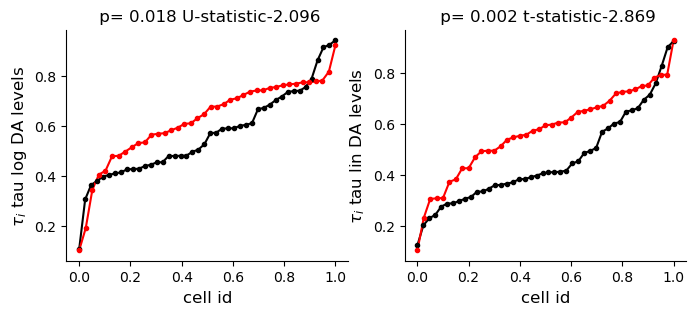

In [102]:

name_preffs = ['tau_log','tau_lin']
var_names_x = ['DA_levels']
to_test = [[taus_log],[taus_v]]
name_suff = [vi for vi in var_names_x]
alternative = 'less'

fig,ax = plt.subplots(1,2,figsize=(8,3))
for ((iis,name_preff),gtest) in zip(enumerate(name_preffs),to_test):
    groups_test = [[ ti[:,i][~np.isnan(ti[:,i])] for i in range(2) ] for ti in gtest]
    tests_pd = get_tests_table(groups_test, name_preff, name_suff,alternative=alternative,tests_pd=tests_pd)
    gnames = name_preff + '_'+name_suff[0]
    ll = len(tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] == name_preff +'_all')].pvals.to_numpy()[0])
    ss = np.sum(tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] ==name_preff +'_all')].pvals.to_numpy()[0]>.05)
    if ll>ss:
        pvals = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gnames)].pvals.to_numpy()[0]
        stats_p = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gnames)].stats.to_numpy()[0]  
        stats_n = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gnames)].stat_name.to_numpy()[0]  
        test_n = 'ranksum'
    else:
        pvals = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] ==gnames)].pvals.to_numpy()[0]
        stats_p = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] == gnames)].stats.to_numpy()[0]   
        stats_n = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] == gnames)].stat_name.to_numpy()[0]  
        test_n = 't-test'    
    [ax[iis].plot(np.linspace(0,1,len(groups_test[0][ig])),np.sort(groups_test[0][ig]),color=colors_g[ig]) for ig in range(2) ] 
    [ax[iis].plot(np.linspace(0,1,len(groups_test[0][ig])),np.sort(groups_test[0][ig]),'.',color=colors_g[ig]) for ig in range(2) ] 
    ax[iis].set_title(' p= '+str(np.floor(pvals*1000)/1000) + ' '+stats_n+ str(np.floor(stats_p*1000)/1000) )
    plot_config(ax[iis],'cell id',r'$\tau_i$' + ' '+gnames.replace('_',' '),12,False) 

## Figure 6h
Compute tuning curves : change in D1R and D2R occupancy as a function of changes in DA concentration

/var/folders/7s/h7n9pv413rl46rgzy1w1w54w0000gn/T/ipykernel_60462/2549501987.py:25: RuntimeWarning: Mean of empty slice
  utility_axis = np.nanmean(mu_da,axis=1)
/Users/sromeropinto/Dropbox (Uchida Lab)/Sandra Romeo/Manuscript D1D2/code/D1D2_Dopamine/utils/drl.py:101: RuntimeWarning: Mean of empty slice
  zero_crossings_mu = np.nanmean(zero_crossings)


[None, None]

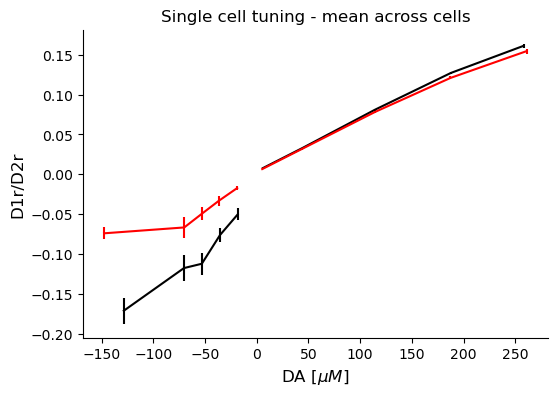

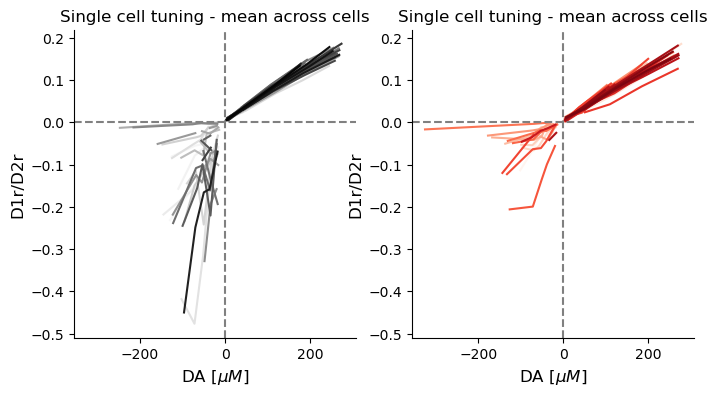

In [103]:
n_bins= 5
da_pos_cells = np.zeros((2,45,n_bins))
da_neg_cells = np.zeros((2,45,n_bins))
rec_d1_cells = np.zeros((2,45,n_bins))
rec_d2_cells = np.zeros((2,45,n_bins))
id_x_var=1
bins_pos  = np.linspace(10,300,n_bins)
bins_neg  = np.linspace(-80,-10,n_bins)
for i_group in  np.arange(2):
    tr_var_cells =trial_var_cells.copy()
    per_cell = tr_var_cells[i_group,1,i_win_us,:,:,:]
    base_cells = tr_var_cells[i_group,1,i_win_base,:,:,:] 
    rec_d1 = tr_var_cells[i_group,2,i_win_us,:,:,:]
    base_d1 = tr_var_cells[i_group,2,i_win_base,:,:,:]
    rec_d2 =  tr_var_cells[i_group,3,i_win_us,:,:,:]
    base_d2 = tr_var_cells[i_group,3,i_win_base,:,:,:]
    d_da = per_cell - base_cells
    d_d1 = rec_d1 - base_d1
    d_d2 = rec_d2 - base_d2

    for i_cell in  range(per_cell.shape[0]):
        mu_da = d_da[i_cell,:,:]
        mu_rec_d1 = d_d1[i_cell,:,:]
        mu_rec_d2 = d_d2[i_cell,:,:]
        utility_axis = np.nanmean(mu_da,axis=1)
        zcr_da = utils.compute_zero_crossings(mu_da,utility_axis,1, method_zcross) 
        zcr_i = np.floor(np.interp(zcr_da[0][0],utility_axis,np.arange(6)))  
        if not np.isnan(zcr_i):
            da_pos,da_neg,rec_pos,rec_neg = utils.get_pos_neg_regime_variables(zcr_i,mu_da,mu_rec_d1,mu_rec_d2,truncate_reg=True)
            da_pos_cells[i_group,i_cell,:], rec_d1_cells[i_group,i_cell,:] = digitize_responses(da_pos, rec_pos,bins_pos)
            da_neg_cells[i_group,i_cell,:], rec_d2_cells[i_group,i_cell,:]  =digitize_responses(da_neg, rec_neg,bins_neg)

# Lesion has less neurons, take out zero: 
da_pos_cells[da_pos_cells==0]=np.nan
da_neg_cells[da_neg_cells==0]=np.nan
rec_d1_cells[rec_d1_cells==0]=np.nan
rec_d2_cells[rec_d2_cells==0]=np.nan

# Single cell tuning:  mean across neurns
fig,ax = plt.subplots(figsize=(6,4))
[ax.errorbar(np.nanmean(da_pos_cells[ig,:,:],axis=0),np.nanmean(rec_d1_cells[ig,:,:],axis=0),
          np.nanstd(rec_d1_cells[ig,:,:],axis=0)/np.sqrt(n_cells),color=colors_g[ig]) for ig in range(2)]
[ax.errorbar(np.nanmean(da_neg_cells[ig,:,:],axis=0),np.nanmean(rec_d2_cells[ig,:,:],axis=0),
          np.nanstd(rec_d2_cells[ig,:,:],axis=0)/np.sqrt(n_cells),color=colors_g[ig]) for ig in range(2)]
plot_config(ax,r'DA [$\mu M$]','D1r/D2r',12, False)
title_(ax,'Single cell tuning - mean across cells')

# Single cell tuning:  plot single neurns
cmaps = [cm.Greys,cm.Reds]
fig,ax = plt.subplots(1,2,figsize=(8,4))
_ = [[ax[ig].plot(da_pos_cells[ig,icell,:],rec_d1_cells[ig,icell,:],color=cmaps[ig](icell/n_cells)) for icell in range(n_cells)] for ig in range(2)]
_ = [[ax[ig].plot(da_neg_cells[ig,icell,:],rec_d2_cells[ig,icell,:],color=cmaps[ig](icell/n_cells)) for icell in range(n_cells)] for ig in range(2)]
[title_(ia,'Single cell tuning - mean across cells') for ia in ax]
xl = limit_xaxis(ax)
yl = limit_yaxis(ax)
[ia.plot([np.min(xl),np.max(xl)],[0,0],'--',color='grey') for ia in ax]
[ia.plot([0,0],[np.min(yl),np.max(yl)],'--',color='grey') for ia in ax]
[plot_config(ia,r'DA [$\mu M$]','D1r/D2r',12, False) for ia in ax]



**Compute $\tau$ with the mean response across population**


Similar process as above :

1. Select independent variable = Input firing rate (id = 0), DA concentration (id = 1) in `id_vars_x`
2. Select dependent variables = D1 occupancy for positive responses, D2 occupancy for negative responses
   
      Select the epoch responses at US and at baseline for each variable and perform baseline subtraction

3. Chose a random set of trials and neurons per iteration
4. Compute **utility axis** based on the mean across neurons and trials for the indpendent variable
5. Compute the **zero crossing points** based on the mean across neurons
6. Compute the **asymmetric learning rates** ($\alpha_i^+$,$\alpha_i^-$) based on the mean across neurons using the zero crossing point from step (5). 
7. Compute the **asymmetric scaling factor** ($\tau_i = \frac{\alpha_i^+}{\alpha_i^+ + \alpha_i^-}$) 

Perform the steps (1-7) for 100 iterations (`niterations`)

Output variable:

- `taus_lin_pop`: distribution of $tau$ across iterations randomly sampling from trials and neurons (N groups x N iterations)

In [104]:
#% % Eta at population  level : 
niterations = 100
n_pseudo_trials= 300
n_cells = 45
i_win_base = 2
i_win_us = 1
iio  = 0
method_regress = 'siegelslopes'
method_zcross = 'count'
taus_lin_pop = np.zeros((2,niterations))

for i_group in np.arange(2):
    tr_var_cells = trial_var_cells.copy()
    base_cells = tr_var_cells[i_group,1,i_win_base,:,:,:]
    per_cell = tr_var_cells[i_group,1,i_win_us,:,:,:]
    per_cell = per_cell-base_cells
    utility_axis =np.nanmean(np.nanmean(per_cell,axis=2),axis=0)
    da_us =  tr_var_cells[i_group,1,i_win_us,:,:,:]
    rec_occ_pos =  tr_var_cells[i_group,2,i_win_us,:,:,:]
    rec_occ_neg = tr_var_cells[i_group,3,i_win_us,:,:,:]
    da_base = tr_var_cells[i_group,1,i_win_base,:,:,:]
    occ_base_pos = tr_var_cells[i_group,2,i_win_base,:,:,:]
    occ_base_neg = tr_var_cells[i_group,3,i_win_base,:,:,:]
    (da_us,rec_occ_pos,rec_occ_neg,da_base,occ_base_pos,occ_base_neg) = [replace_zeros_to_nan(var) for var in [da_us,rec_occ_pos,rec_occ_neg,da_base,occ_base_pos,occ_base_neg]]
    notnan = np.argwhere(~np.isnan(per_cell))
    trial_max = np.max(notnan[:,2])
    id_cells = [np.random.choice(np.arange(per_cell.shape[0]),per_cell.shape[0]) for _ in range(niterations)]
    id_trials = [np.random.choice(np.arange(trial_max),n_pseudo_trials) for _ in range(niterations)]
    utility_axis = [np.floor(np.nanmean(np.nanmean(per_cell[ids,:,:][:,:,idt],axis=2),axis=0)*1000)/1000  for (idt,ids) in zip(id_trials,id_cells)]
    zcr = [utils.compute_zero_crossings(np.nanmean(per_cell[ids,:,:][:,:,idt],axis=0),uaxis,1,method_zcross)[0][0] for (idt,ids,uaxis) in zip(id_trials,id_cells,utility_axis)]
    zcr_i = [np.round(np.interp(zcri,uaxis,np.arange(6)))  for (uaxis,zcri) in zip(utility_axis,zcr)]
    id_neg = [np.int0(np.arange(zcri)) for zcri in zcr_i]
    id_pos = [np.int0(np.arange(zcri,6)) for zcri in zcr_i]
    xx_pos = [np.nanmean(da_us[ids,:,:][:,:,idt]-da_base[ids,:,:][:,:,idt],axis=0)[ipos].flatten() for (idt,ids,ipos) in zip(id_trials,id_cells,id_pos)]
    yy_pos = [np.nanmean(rec_occ_pos[ids,:,:][:,:,idt]-occ_base_pos[ids,:,:][:,:,idt],axis=0)[ipos].flatten() for (idt,ids,ipos) in zip(id_trials,id_cells,id_pos)]
    xx_neg= [np.nanmean(da_us[ids,:,:][:,:,idt]-da_base[ids,:,:][:,:,idt],axis=0)[ineg].flatten() for (idt,ids,ineg) in zip(id_trials,id_cells,id_neg)]
    yy_neg = [np.nanmean(rec_occ_neg[ids,:,:][:,:,idt]-occ_base_neg[ids,:,:][:,:,idt],axis=0)[ineg].flatten() for (idt,ids,ineg) in zip(id_trials,id_cells,id_neg)]
    m = [utils.compute_asymmetric_scaling_receptor(xxp,xxp_l,yyp,xxn,xxn_l,yyn_neg,method_regress=method_regress) for (xxp,xxp_l,yyp,xxn,xxn_l,yyn_neg) in zip(xx_pos,xx_pos,yy_pos,xx_neg,xx_neg,yy_neg)]
    taus_lin_= np.asarray([im[1] for im in m])
    taus_lin_pop[i_group,:] = taus_lin_

/var/folders/7s/h7n9pv413rl46rgzy1w1w54w0000gn/T/ipykernel_60462/4239903913.py:30: RuntimeWarning: Mean of empty slice
  zcr = [utils.compute_zero_crossings(np.nanmean(per_cell[ids,:,:][:,:,idt],axis=0),uaxis,1,method_zcross)[0][0] for (idt,ids,uaxis) in zip(id_trials,id_cells,utility_axis)]
/var/folders/7s/h7n9pv413rl46rgzy1w1w54w0000gn/T/ipykernel_60462/4239903913.py:32: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  id_neg = [np.int0(np.arange(zcri)) for zcri in zcr_i]
/var/folders/7s/h7n9pv413rl46rgzy1w1w54w0000gn/T/ipykernel_60462/4239903913.py:33: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  id_pos = [np.int0(np.arange(zcri,6)) for zcri in zcr_i]
/var/folders/7s/h7n9pv413rl46rgzy1w1w54w0000gn/T/ipykernel_60462/4239903913.py:34: RuntimeWarning: Mean of empty slice
  xx_pos = [np.nanmean(da_us[ids,:,:][:,:,idt]-da_base[ids,:,:][:,:,idt],axis=0)[ipos].flatten() for (idt,ids,ipos) in zip(i

## Figure 6i

**Plot of distributions of $\tau$ across iterations**

The null hypothesis can be rejected: not drawn from a normal distribution


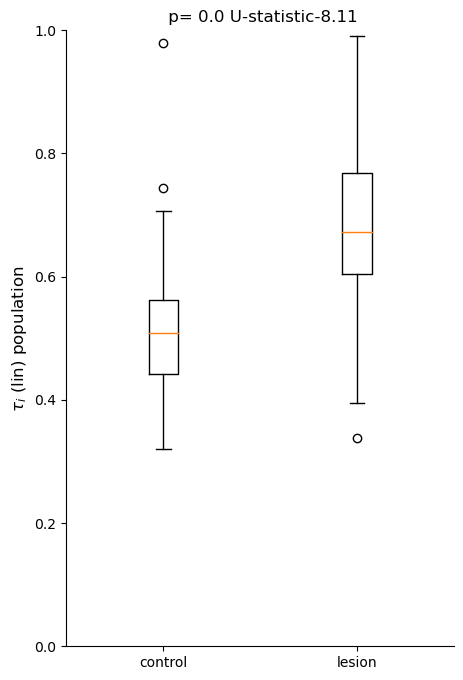

In [105]:
#% % Box plot for populatiob taus:
alternative = 'less'
to_test = [taus_lin_pop]
name_preffs= ['tau_lin_pop']
tit_suff = ['lin']
name_suff = 'd'
for (taus_pop,name_preff,itit) in zip(to_test,name_preffs,tit_suff):
    fig,ax = plt.subplots(figsize=(5,8))
    taulist = [taus_pop[ig,:][(taus_pop[ig,:]<1)*(taus_pop[ig,:]>0)] for ig in range(2)]
    ax.boxplot(taulist)  
    tests_pd = get_tests_table([taulist], name_preff, name_suff,alternative=alternative,tests_pd=tests_pd)
    gnames =name_preff+ '_'+name_suff
    ll = len(tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] == name_preff +'_all')].pvals.to_numpy()[0])
    ss = np.sum(tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] ==name_preff +'_all')].pvals.to_numpy()[0]>.05)
    if ll>ss:
        pvals = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gnames)].pvals.to_numpy()[0]
        stats_p = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gnames)].stats.to_numpy()[0]  
        stats_n = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gnames)].stat_name.to_numpy()[0]  
        test_n = 'ranksum'
    else:
        pvals = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] ==gnames)].pvals.to_numpy()[0]
        stats_p = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] == gnames)].stats.to_numpy()[0]   
        stats_n = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] == gnames)].stat_name.to_numpy()[0]  
        test_n = 't-test'  
    ax.set_title(' p= '+str(np.floor(pvals*10000)/10000) + ' '+stats_n+ str(np.floor(stats_p*1000)/1000) ) 
    plot_config(ax,'',r'$\tau_i$ ('+itit+') population',12,False) 
    ax.set_xticklabels( groups)
    ax.set_ylim([.0,1]) 

tests_pd.to_excel("analysis/lhb_data/drl_from_data.xlsx")  